<a href="https://colab.research.google.com/github/vamsiram89/ML-Projects/blob/ML/Gold_price_prediction_By_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn import metrics

Data collection and processing

In [ ]:
df = pd.read_csv("/content/sample_data/gld_price_data.csv")
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


**No of rows and columns**

In [ ]:
df.shape

(2290, 6)

**Getting the information about the data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


**Check the number of missing values**

In [ ]:
df.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


**Getting the statistical information about the data**

In [ ]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


**Correlation**

**1.positive correlation**


**2.Negative correlation**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
correlation = df.select_dtypes(include=np.number).corr()

<Axes: >

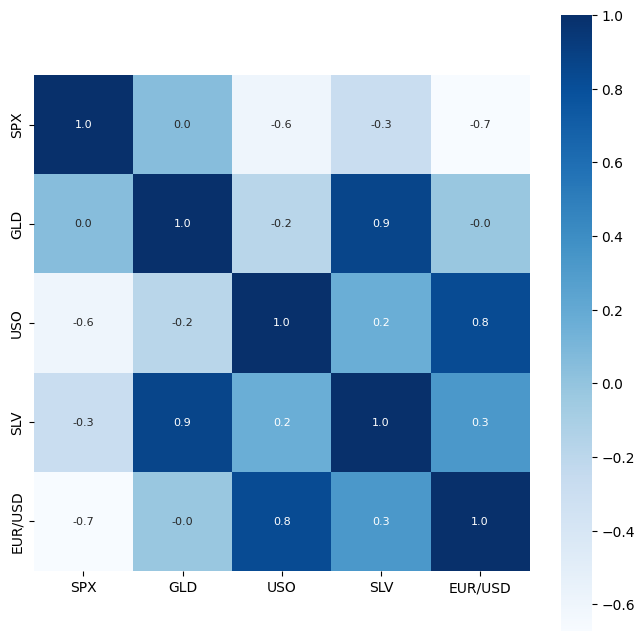

In [ ]:
# construction a heatmap to understand the correlation
plt.figure(figsize = (8,8))
sns.heatmap(correlation,cbar = True,square = True,fmt = '.1f',annot = True,annot_kws = {'size':8},cmap = 'Blues')

In [ ]:
# corelation values of gold
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_9504/501824861.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['GLD'],color = 'green')


<Axes: xlabel='GLD', ylabel='Density'>

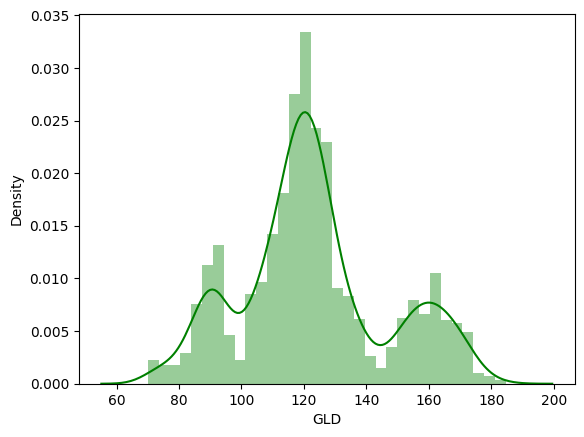

In [ ]:
# checking the distribution of the gold price
sns.distplot(df['GLD'],color = 'green')

**Splitting the features and Target**

In [ ]:
x = df.drop(['Date','GLD'],axis = 1)
y = df['GLD']

In [ ]:
x

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.1800,1.471692
1,1447.160034,78.370003,15.2850,1.474491
2,1411.630005,77.309998,15.1670,1.475492
3,1416.180054,75.500000,15.0530,1.468299
4,1390.189941,76.059998,15.5900,1.557099
...,...,...,...,...
2285,2671.919922,14.060000,15.5100,1.186789
2286,2697.790039,14.370000,15.5300,1.184722
2287,2723.070068,14.410000,15.7400,1.191753
2288,2730.129883,14.380000,15.5600,1.193118


In [ ]:
y

,GLD
0,84.860001
1,85.570000
2,85.129997
3,84.769997
4,86.779999
...,...
2285,124.589996
2286,124.330002
2287,125.180000
2288,124.489998


**Splitting into training and Testing data**

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 2)


**Model training Random Forest Regressor**

In [ ]:
regressor = RandomForestRegressor(n_estimators = 100)
regressor.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
# Training the model
regressor.fit(x_train,y_train)

RandomForestRegressor()

**Model Evaluation**

In [ ]:
# prediction on test data
test_data_prediction = regressor.predict(x_test)

In [ ]:
print(test_data_prediction)


[168.42949952  82.02929963 116.06120004 127.68260104 120.92750146
 154.68529736 149.87879874 126.13150012 117.56439874 125.95550077
 116.8176007  171.7137007  141.62719824 167.88499832 115.01310007
 117.19110056 138.48190295 170.32980033 159.60590322 157.24219913
 155.22430019 125.32179969 175.29119958 157.32060349 125.33320042
  93.64569967  78.00189974 120.44999979 119.07709938 167.52749934
  88.2632006  125.33690025  91.12590063 117.64990051 121.18659917
 136.26490052 115.59990102 115.43890076 148.55869985 106.94550095
 104.46520237  87.12669793 126.36230062 117.83020018 153.8897992
 119.72450008 108.2924996  108.06479819  93.11630016 127.04349804
  75.12050001 113.54659948 121.09640007 111.1885989  118.91749911
 120.47159941 159.32380027 169.73470062 147.02449738  85.77059871
  94.34170023  86.75849843  90.61019987 118.87820072 126.41810096
 127.56330015 169.80879996 122.36819971 117.47259894  98.2777004
 168.3190012  143.11989829 131.85550194 121.13210235 120.94259949
 119.8392006

In [ ]:
# R squared error
error_score = metrics.r2_score(y_test,test_data_prediction)
print("R squared error : ",error_score)


R squared error :  0.9886982462533751


**compare the actual values and predicted values in a plot**

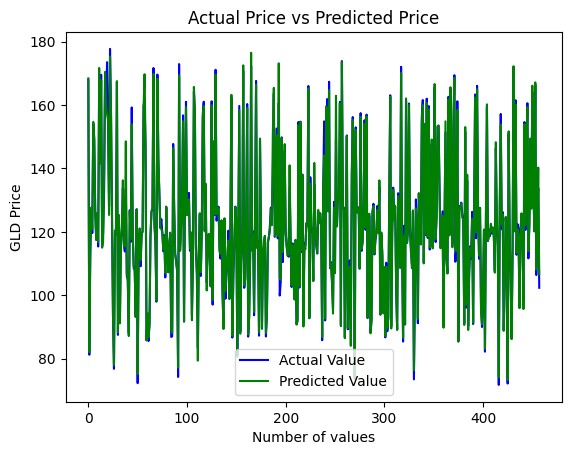

In [ ]:
y_test = list(y_test)
plt.plot(y_test,color = 'blue',label = 'Actual Value')
plt.plot(test_data_prediction,color = 'green',label = 'Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()
